In [7]:
#the wing we are designing is bounded by 3 criterion based upon the wind tunnel available,
#the max velocity we can achieve is around 40 m/s and our wind tunnel section has a width of
#1600 mm or 1.6 meters to achieve an aspect ratio similar to the goland wing of 12 we will 
#also have a chord constraint to scale relative to our span, the goland wing is roughly 6.1 
#metres by 1.8 metres

import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main

u_inf = 1.
alpha_deg = 2.  # Define angle of attack for static aeroelastic analysis.
rho = 1.02      # Air density. #inquire about this for our wind tunnel

M = 16             # Number of chordwise panels
N = 32             # Number of spanwise panels
M_star_fact = 10   # Length of the wake in chords.
num_modes =  8     # Number of vibration modes retained in the structural model.

c_ref = .2 
rom_settings = dict()
rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
rom_settings['r'] = 6  # Krylov subspace order
frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
frequency_continuous_w = 2 * u_inf * frequency_continuous_k / c_ref
rom_settings['frequency'] = frequency_continuous_w

case_name = 'mycase4'
route_test_dir = os.path.abspath('')

print('The case to run will be: %s' % case_name)
print('Case files will be saved in ./cases/%s' %case_name)
print('Output files will be saved in ./output/%s/' %case_name)

#let us assume we are making a wing that is half the size, thus let us set our b_ref to 1.2 metres
#to achieve an aspect ratio of 12 we need 2*1.2/x = 12 leading to our chord of 0.2 metres
ws = wings.Goland(M=M,
                  N=N,
                  Mstar_fact=M_star_fact,
                  u_inf=u_inf,
                  alpha=alpha_deg,
                  rho=rho,
                  b_ref=2. * 1.2,
                  main_chord= 0.2,
                  aspect_ratio=(2. * 1.2) / 0.2,
                  sweep=0,
                  physical_time=2,
                  n_surfaces=2,
                  route = route_test_dir + '/cases',
                  case_name=case_name
                  )

def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra

    #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
    #structural properties appropriately to achieve flutter, (as lift forces are proportional
    #to the wing area)
    width = 100E-3
    height = 4E-3
    E = 69e9  # Young's modulus in Pascals (Pa)
    G = 26e9  # Shear modulus in Pascals (Pa)
    rho = 2700

    # Cross-sectional properties
    A = width * height  # Area in m²
    Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
    Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
    print(Iy)
    print(Iz)
    J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

    # Rigidity calculations
    EA = E * A
    GA = G * A
    GJ = G * J
    EIy = E * Iy
    EIz = E * Iz

    ea, ga = EA, GA
    gj = GJ
    eiy = EIy
    eiz = EIz
    base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(base_stiffness)
    
    m_unit = 7
    j_tors = (Iy+Iz)*rho
    print(Iy+Iz)
    print(j_tors)
    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                    j_tors, .1 * j_tors, .9 * j_tors])

    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

ws.update_mass_stiff = new_update_mass_stiff.__get__(ws, wings.Goland)   
ws.clean_test_files()
ws.update_derived_params()
ws.set_default_config_dict()

ws.generate_aero_file()
ws.generate_fem_file()

The case to run will be: mycase4
Case files will be saved in ./cases/mycase4
Output files will be saved in ./output/mycase4/
5.333333333333335e-10
3.333333333333334e-07
[[2.76000000e+07 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.04000000e+07 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.04000000e+07 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.10933333e+02 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.68000000e+01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.30000000e+04]]
3.3386666666666674e-07
0.0009014400000000002


In [8]:
ws.config['SHARPy'] = {
    'flow':
        ['BeamLoader', 'AerogridLoader',
         'StaticCoupled',
         'AerogridPlot',
         'BeamPlot',
         'Modal',
         'LinearAssembler',
         'AsymptoticStability',
         ],
    'case': ws.case_name, 'route': ws.route,
    'write_screen': 'off', 'write_log': 'on',    # Change to 'on' as neded.
    'log_folder': route_test_dir + '/output/',
    'log_file': ws.case_name + '.log'}

ws.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': ws.quat}

ws.config['AerogridLoader'] = {
    'unsteady': 'off',
    'aligned_grid': 'on',
    'mstar': ws.Mstar_fact * ws.M,
    'freestream_dir': ws.u_inf_direction,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {'u_inf': ws.u_inf,
                                    'u_inf_direction': ws.u_inf_direction,
                                    'dt': ws.dt}}

ws.config['StaticCoupled'] = {
    'print_info': 'on',
    'max_iter': 200,
    'n_load_steps': 1,
    'tolerance': 1e-10,
    'relaxation_factor': 0.,
    'aero_solver': 'StaticUvlm',
    'aero_solver_settings': {
        'rho': ws.rho,
        'print_info': 'off',
        'horseshoe': 'off',
        'num_cores': 4,
        'n_rollup': 0,
        'rollup_dt': ws.dt,
        'rollup_aic_refresh': 1,
        'rollup_tolerance': 1e-4,
        'velocity_field_generator': 'SteadyVelocityField',
        'velocity_field_input': {
            'u_inf': ws.u_inf,
            'u_inf_direction': ws.u_inf_direction}},
    'structural_solver': 'NonLinearStatic',
    'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 150,
                                   'num_load_steps': 4,
                                   'delta_curved': 1e-1,
                                   'min_delta': 1e-10,
                                   'gravity_on': 'on',
                                   'gravity': 9.81}}

ws.config['AerogridPlot'] = {'include_rbm': 'off',
                             'include_applied_forces': 'on',
                             'minus_m_star': 0}

ws.config['BeamPlot'] = {'include_rbm': 'off',
                         'include_applied_forces': 'on'}

ws.config['Modal'] = {'NumLambda': 20,
                      'rigid_body_modes': 'off',
                      'print_matrices': 'on', # 'keep_linear_matrices': 'on',            'write_dat': 'off',
                      'rigid_modes_cg': 'off',
                      'continuous_eigenvalues': 'off',
                      'dt': 0,
                      'plot_eigenvalues': False,
                      'max_rotation_deg': 15.,
                      'max_displacement': 0.15,
                      'write_modes_vtk': True,
                      'use_undamped_modes': True}

ws.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': 'on',
                                                      'inout_coords': 'modes',
                                                      'discrete_time': 'on',
                                                      'newmark_damp': 0.5e-4,
                                                      'discr_method': 'newmark',
                                                      'dt': ws.dt,
                                                      'proj_modes': 'undamped',
                                                      'use_euler': 'off',
                                                      'num_modes': num_modes,
                                                      'print_info': 'on',
                                                      'gravity': 'on',
                                                      'remove_sym_modes': 'on',
                                                      'remove_dofs': []},
                                    'aero_settings': {'dt': ws.dt,
                                                      'ScalingDict': {'length': 0.5 * ws.c_ref,
                                                                      'speed': u_inf,
                                                                      'density': rho},
                                                      'integr_order': 2,
                                                      'density': ws.rho,
                                                      'remove_predictor': 'on',
                                                      'use_sparse': 'on',
                                                      'remove_inputs': ['u_gust'],
                                                      'rom_method': ['Krylov'],
                                                      'rom_method_settings': {'Krylov': rom_settings}},
                                    }}

ws.config['AsymptoticStability'] = {'print_info': True,
                                    'velocity_analysis': [10, 100, 81],
                                   'modes_to_plot': []}
                                    

ws.config.write()
                            

In [9]:
sharpy_output = sharpy.sharpy_main.main(['', ws.route + ws.case_name + '.sharpy'])

fatal: not a git repository (or any of the parent directories): .git
/home/password/.local/lib/python3.10/site-packages/sharpy/solvers/modal.py:289: RuntimeWarning: invalid value encountered in sqrt
  freq_natural = np.sqrt(eigenvalues)
/home/password/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '
/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:1217: RuntimeWarning: invalid value encountered in sqrt
  omega = np.sqrt(eigenvalues)
/home/password/.local/lib/python3.10

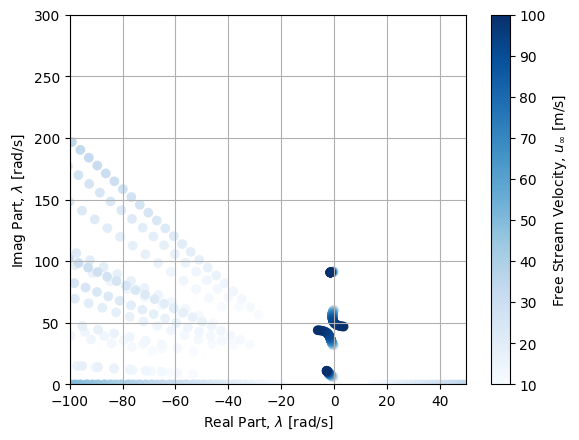

In [10]:
file_name = './output/%s/stability/velocity_analysis_min0100_max1000_nvel0081.dat' % case_name

velocity_analysis = np.loadtxt(file_name)
u_inf = velocity_analysis[:, 0]
eigs_r = velocity_analysis[:, 1]
eigs_i = velocity_analysis[:, 2]

fig = plt.figure()
plt.scatter(eigs_r, eigs_i, c=u_inf, cmap='Blues')
cbar = plt.colorbar()
cbar.set_label('Free Stream Velocity, $u_\infty$ [m/s]')

plt.grid()
plt.xlim(-100, 50)
plt.ylim(0, 300)
plt.xlabel('Real Part, $\lambda$ [rad/s]')
plt.ylabel('Imag Part, $\lambda$ [rad/s]');

[ 10.     10.     10.     10.     10.     10.     10.     10.     10.     11.125  11.125  11.125  11.125  11.125
  11.125  11.125  11.125  11.125  12.25   12.25   12.25   12.25   12.25   12.25   12.25   12.25   12.25   13.375
  13.375  13.375  13.375  13.375  13.375  13.375  13.375  14.5    14.5    14.5    14.5    14.5    14.5    14.5
  14.5    15.625  15.625  15.625  15.625  15.625  15.625  15.625  15.625  16.75   16.75   16.75   16.75   16.75
  16.75   16.75   16.75   17.875  17.875  17.875  17.875  17.875  17.875  17.875  17.875  19.     19.     19.
  19.     19.     19.     19.     19.     20.125  20.125  20.125  20.125  20.125  20.125  20.125  20.125  21.25
  21.25   21.25   21.25   21.25   21.25   21.25   21.25   22.375  22.375  22.375  22.375  22.375  22.375  22.375
  22.375  23.5    23.5    23.5    23.5    23.5    23.5    23.5    23.5    24.625  24.625  24.625  24.625  24.625
  24.625  24.625  24.625  25.75   25.75   25.75   25.75   25.75   25.75   25.75   25.75   26.875  26.87

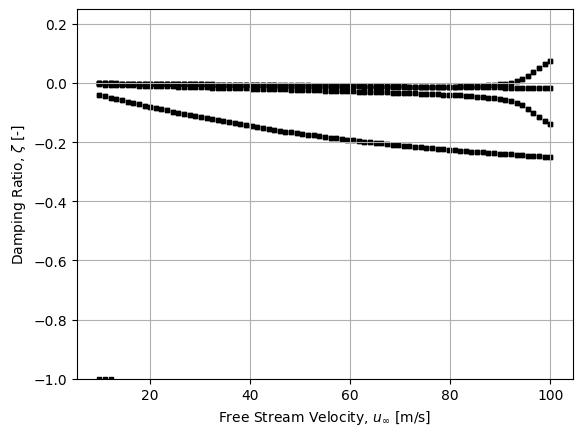

In [11]:
fig = plt.figure()
natural_frequency = np.sqrt(eigs_r ** 2 + eigs_i ** 2)
damping_ratio = eigs_r / natural_frequency
cond = (eigs_r>-25) * (eigs_r<10) * (natural_frequency<100) # filter unwanted eigenvalues for this plot (mostly aero modes)

print(u_inf[cond])
print(damping_ratio[cond])
plt.scatter(u_inf[cond], damping_ratio[cond], color='k', marker='s', s=9)

plt.grid()
plt.ylim(-1, 0.25)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Damping Ratio, $\zeta$ [-]');

[ 10.     10.     10.     10.     10.     10.     10.     10.     10.     11.125  11.125  11.125  11.125  11.125
  11.125  11.125  11.125  11.125  12.25   12.25   12.25   12.25   12.25   12.25   12.25   12.25   12.25   13.375
  13.375  13.375  13.375  13.375  13.375  13.375  13.375  14.5    14.5    14.5    14.5    14.5    14.5    14.5
  14.5    15.625  15.625  15.625  15.625  15.625  15.625  15.625  15.625  16.75   16.75   16.75   16.75   16.75
  16.75   16.75   16.75   17.875  17.875  17.875  17.875  17.875  17.875  17.875  17.875  19.     19.     19.
  19.     19.     19.     19.     19.     20.125  20.125  20.125  20.125  20.125  20.125  20.125  20.125  21.25
  21.25   21.25   21.25   21.25   21.25   21.25   21.25   22.375  22.375  22.375  22.375  22.375  22.375  22.375
  22.375  23.5    23.5    23.5    23.5    23.5    23.5    23.5    23.5    24.625  24.625  24.625  24.625  24.625
  24.625  24.625  24.625  25.75   25.75   25.75   25.75   25.75   25.75   25.75   25.75   26.875  26.87

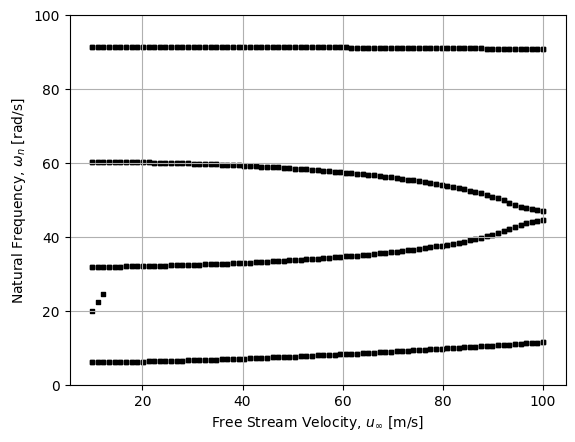

In [12]:
fig = plt.figure()
cond = (eigs_r>-25) * (eigs_r<10) # filter unwanted eigenvalues for this plot (mostly aero modes)
plt.scatter(u_inf[cond], natural_frequency[cond], color='k', marker='s', s=9)
print(u_inf[cond])
print(natural_frequency[cond])
plt.grid()
plt.ylim(0, 100)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Natural Frequency, $\omega_n$ [rad/s]');